---
tags: [algorithm, primitive, resource-estimation]
---

# 量子フーリエ変換（QFT）入門

量子フーリエ変換（Quantum Fourier Transformation; QFT）は、離散フーリエ変換の量子版です。量子位相推定やShorのアルゴリズム{cite:p}`10.1109/SFCS.1994.365700`など、量子振幅に埋め込まれた位相情報を使うアルゴリズムで、重要なサブルーチンとして使われます{cite:p}`10.48550/arXiv.quant-ph/0201067`。

このノートブックでは、古典のフーリエ変換から始めてQFT回路を説明し、4量子ビットの周波数推定の例をQamomileで実装します。QFT回路の描画、ローカルのQiskitシミュレータでの実行、ヒストグラムからの周波数推定、計算量のスケーリングの確認までを扱います。

In [1]:
# 最新のQamomileをpipからインストールします！
# !pip install qamomile

In [2]:
import math

import matplotlib.pyplot as plt
import numpy as np

import qamomile.circuit as qmc
from qamomile.circuit.stdlib.qft import qft
from qamomile.qiskit import QiskitTranspiler
from qiskit_aer import AerSimulator

transpiler = QiskitTranspiler()

## 背景: フーリエ変換

フーリエ変換は、データを周波数成分として表し、各周波数がどれだけ含まれているかを調べる方法です。有限長のベクトルに対してよく使うのが**離散フーリエ変換**（Discrete Fourier Transform、DFT）です。

ベクトル$x = (x_0, x_1, \ldots, x_{N-1})$に対して、このノートブックでは次の正規化を使います。

$$
y_k = \frac{1}{\sqrt{N}}\sum_{j=0}^{N-1} x_j e^{2\pi i jk / N},
\qquad k = 0, 1, \ldots, N-1.
$$

出力の添字$k$は周波数成分のインデックスです。このインデックスに対応する角周波数は$2\pi k/N$であり、位相因子$e^{2\pi i jk / N}$により、入力の各位置が異なる位相で足し合わされます。

## アルゴリズム

QFTは、DFTと同じ変換を量子状態の振幅に適用します。$N = 2^n$のとき、整数$x$に対応する計算基底状態$\lvert x\rangle$への作用は次の通りです。

$$
\mathrm{QFT}_N \lvert x \rangle =
\frac{1}{\sqrt{N}}\sum_{k=0}^{N-1} e^{2\pi i xk/N}\lvert k \rangle.
$$

一般の量子状態$\lvert\psi\rangle = \sum_{j=0}^{N-1} a_j\lvert j\rangle$に対しては、QFTは線形性により各計算基底状態$\lvert j\rangle$への作用を重ね合わせた状態を返します。

古典のDFTでは、出力ベクトル全体を得られます。一方で、QFTは量子状態の振幅を変換し、変換後の量子状態を返します。このため、QFTの直後に測定しても、得られるのは変換後の確率分布に従う計算基底の測定結果だけです。ただし、位相推定のようにサブルーチンとして使用する場合は、変換後の位相情報をそのまま利用することができます。

標準的なQFT回路は、アダマールゲート、制御付き位相回転、最後のスワップで構成されます。$n$量子ビットのレジスタでは、$O(n^2)$個のゲートで実装できます。位相を表すために、次の2進小数表記を使います。

$$
[0.x_jx_{j+1}\ldots x_n] =
\frac{x_j}{2}
+ \frac{x_{j+1}}{2^2}
+ \cdots
+ \frac{x_n}{2^{n-j+1}}
=
\sum_{m=j}^{n} \frac{x_m}{2^{m-j+1}}.
$$

### ステップ1：対象量子ビットを1つ選ぶ

レジスタを対象量子ビットごとに処理します。最後の量子ビットにアダマールゲートを適用すると、QFTの出力に現れる最初の因子が得られます。

$x_n=0$なら$H\lvert0\rangle = (\lvert0\rangle + \lvert1\rangle)/\sqrt{2}$です。一方、$x_n=1$なら$H\lvert1\rangle = (\lvert0\rangle - \lvert1\rangle)/\sqrt{2}$であり、これは$e^{2\pi i[0.1]} = e^{\pi i} = -1$を使って同じ形にまとめられます。

$$
\lvert x_n\rangle
\xrightarrow{H}
\frac{1}{\sqrt{2}}
\left(\lvert 0\rangle + e^{2\pi i[0.x_n]}\lvert 1\rangle\right).
$$

### ステップ2：制御付き位相回転を加える

残りの量子ビットからの制御付き位相回転により、2進小数に必要なビットが加わります。対象量子ビット$x_j$に対して、アダマールゲートと制御付き位相回転は次の状態を作ります。

$$
\lvert x_j\rangle
\longmapsto
\frac{1}{\sqrt{2}}
\left(\lvert 0\rangle + e^{2\pi i[0.x_jx_{j+1}\ldots x_n]}\lvert 1\rangle\right).
$$

この位相回転は、一般に$R_k$として次のように書きます。

$$
R_k =
\begin{pmatrix}
1 & 0 \\
0 & e^{2\pi i / 2^k}
\end{pmatrix}.
$$

制御付き$R_k$は、制御量子ビットが$\lvert 1\rangle$のときだけ対象量子ビットにこの回転を適用します。制御位置と対象位置の距離を$d$とすると、QFT回路では制御付き$R_{d+1}$を使います。その回転角は次の通りです。

$$
\theta = \frac{2\pi}{2^{d+1}} = \frac{\pi}{2^d}.
$$

### ステップ3：レジスタ全体で繰り返す

アダマールゲートと制御付き位相回転のパターンを繰り返すと、QFTは次の積の形で書けます。

$$
\mathrm{QFT}\lvert x_1x_2\ldots x_n\rangle =
\frac{1}{\sqrt{2^n}}
\bigotimes_{j=n}^{1}
\left(\lvert 0\rangle + e^{2\pi i[0.x_jx_{j+1}\ldots x_n]}\lvert 1\rangle\right).
$$

4量子ビットの場合は次のようになります。

$$
\mathrm{QFT}_{16}\lvert x_1x_2x_3x_4\rangle =
\frac{1}{\sqrt{16}}
\left(\lvert 0\rangle + e^{2\pi i[0.x_4]}\lvert 1\rangle\right)
\otimes
\left(\lvert 0\rangle + e^{2\pi i[0.x_3x_4]}\lvert 1\rangle\right)
\otimes
\left(\lvert 0\rangle + e^{2\pi i[0.x_2x_3x_4]}\lvert 1\rangle\right)
\otimes
\left(\lvert 0\rangle + e^{2\pi i[0.x_1x_2x_3x_4]}\lvert 1\rangle\right).
$$

### ステップ4：出力順序を反転する

標準的なQFT回路では、出力量子ビットの順序が逆になります。最後にスワップ層を置くことで、レジスタの順序を戻します。一部のアルゴリズムではこのスワップを省き、逆順であることを古典側で管理します。

```{figure} assets/qft_circuit.png
:alt: 標準QFT回路
:width: 720px

n=4のときのQFTの量子回路。
```

## Qamomileでの実装：`qft`関数

`qamomile.circuit.stdlib.qft.qft`関数は、上で説明した回路を適用します。アダマールゲート、制御付き位相回転、最後のスワップをまとめて扱えます。

### 問題例

$N=16$個のサンプルを使うので、4量子ビットで表せます。この例では、計算基底状態$\lvert j\rangle$の振幅を$s_j$とする量子状態を準備します。ここで、$n=4$、$N=16$、$\omega = e^{2\pi i/16}$です。

$$
\lvert \psi_f\rangle =
\sum_{j=0}^{N-1} s_j \lvert j\rangle,
\qquad
s_j = \frac{1}{\sqrt{N}} e^{-2\pi i f j/N}
= \frac{1}{\sqrt{N}}\omega^{-fj},
\qquad f=5,\quad j=0,1,\ldots,N-1.
$$

つまり、$e^{-2\pi i f j/N}$の値を、正規化係数$1/\sqrt{N}$付きで$\lvert \psi_f\rangle$の振幅に埋め込んでいます。この状態にQFTを適用すると、各計算基底状態$\lvert j\rangle$からの寄与が足し合わされ、周波数インデックス$f$だけが残ります。

$$
\mathrm{QFT}_{16}\lvert \psi_f \rangle =
\frac{1}{16}\sum_{j=0}^{15}\sum_{k=0}^{15}\omega^{j(k-f)}\lvert k\rangle
= \lvert f\rangle.
$$

したがって、$f=5$のとき、出力は周波数インデックス$k=5$に集中するはずです。実際に古典DFTを実行して確かめてみましょう。NumPyの`np.fft.ifft`を利用して計算します。

In [3]:
num_qubits = 4
dimension = 2**num_qubits
frequency = 5
positions = np.arange(dimension)

signal = np.exp(-2j * np.pi * frequency * positions / dimension) / np.sqrt(dimension)
spectrum = np.fft.ifft(signal, norm="ortho")
expected_spectrum = np.zeros(dimension, dtype=complex)
expected_spectrum[frequency] = 1.0

print(np.round(np.abs(spectrum), 3))
assert np.allclose(spectrum, expected_spectrum)

[0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


### `qft`による量子カーネルの実装

Qamomileでは、標準ライブラリ関数`qamomile.circuit.stdlib.qft.qft`としてQFTを使えます。この関数は`Vector[Qubit]`を受け取り、レジスタ全体にQFTを適用して、変換後のベクトルを返します。

次の状態準備では、振幅に直接位相パターンを作ります。`q[0]`をサンプルインデックス$j$の最下位ビットとして扱うため、各量子ビットに加える位相は左から右へ2倍ずつ大きくなります。

In [4]:
@qmc.qkernel
def qft_frequency_estimator() -> qmc.Vector[qmc.Bit]:
    q = qmc.qubit_array(num_qubits, name="q")

    # すべてのサンプルインデックスの一様重ね合わせを作ります。
    q = qmc.h(q)

    # 位相パターン exp(-2πi f j / N) を振幅に埋め込みます。
    q[0] = qmc.p(q[0], -2 * math.pi * frequency / dimension)
    q[1] = qmc.p(q[1], -2 * math.pi * frequency * 2 / dimension)
    q[2] = qmc.p(q[2], -2 * math.pi * frequency * 4 / dimension)
    q[3] = qmc.p(q[3], -2 * math.pi * frequency * 8 / dimension)

    # QFTを適用し、周波数インデックスを測定します。
    q = qft(q)
    return qmc.measure(q)

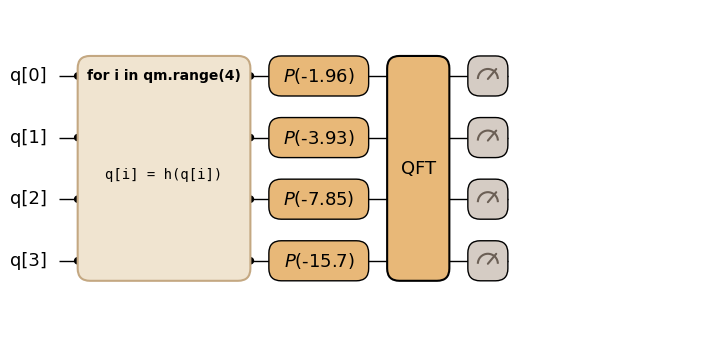

In [5]:
qft_frequency_estimator.draw()

`draw()`では、QFTが1つの演算として表示されます。トランスパイル後のQiskit回路を見たい場合は、`to_circuit`で変換します。

In [6]:
qiskit_circuit = transpiler.to_circuit(qft_frequency_estimator)
print(qiskit_circuit.draw())

     ┌───┐┌──────────┐┌──────┐┌─┐         
q_0: ┤ H ├┤ P(-5π/8) ├┤0     ├┤M├─────────
     ├───┤├──────────┤│      │└╥┘┌─┐      
q_1: ┤ H ├┤ P(-5π/4) ├┤1     ├─╫─┤M├──────
     ├───┤├──────────┤│  Qft │ ║ └╥┘┌─┐   
q_2: ┤ H ├┤ P(-5π/2) ├┤2     ├─╫──╫─┤M├───
     ├───┤└┬────────┬┘│      │ ║  ║ └╥┘┌─┐
q_3: ┤ H ├─┤ P(-5π) ├─┤3     ├─╫──╫──╫─┤M├
     └───┘ └────────┘ └──────┘ ║  ║  ║ └╥┘
c: 4/══════════════════════════╩══╩══╩══╩═
                               0  1  2  3 


### 実行結果

次に、量子カーネルをローカルで実行し、測定された周波数インデックスのヒストグラムを描きます。下の変換では、上の状態準備に合わせて`q[0]`を最下位ビットとして扱います。

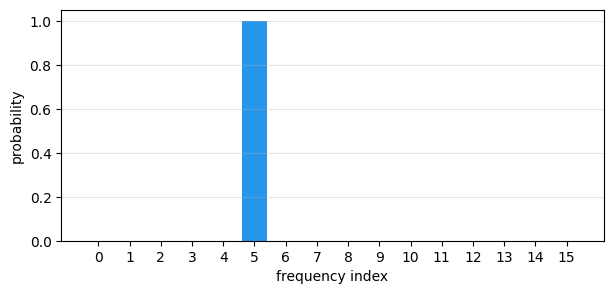

estimated frequency: 5


In [7]:
backend = AerSimulator(seed_simulator=1234, max_parallel_threads=1)
shots = 512
executable = transpiler.transpile(qft_frequency_estimator)
result = executable.sample(transpiler.executor(backend), shots=shots).result()

probabilities = np.zeros(dimension)
for outcome, count in result.results:
    frequency_index = sum(bit << idx for idx, bit in enumerate(outcome))
    probabilities[frequency_index] = count / shots

fig, ax = plt.subplots(figsize=(7, 3))
ax.bar(range(dimension), probabilities, color="#2696EB")
ax.set_xlabel("frequency index")
ax.set_ylabel("probability")
ax.set_xticks(range(dimension))
ax.set_ylim(0, 1.05)
ax.grid(axis="y", alpha=0.3)
plt.show()

estimated_frequency = int(np.argmax(probabilities))
print(f"estimated frequency: {estimated_frequency}")

assert result.shots == shots
assert sum(count for _, count in result.results) == shots
assert estimated_frequency == frequency
assert probabilities[frequency] > 0.95
assert all(
    isinstance(outcome, tuple) and len(outcome) == num_qubits
    for outcome, _ in result.results
)

## リソース推定

厳密なQFT回路では、次のゲートを使います。

- $n$個のアダマールゲート
- $\frac{n(n - 1)}{2}$個の制御付き位相回転
- $\left\lfloor n / 2 \right\rfloor$個のスワップ

したがって総ゲート数は$n + \frac{n(n - 1)}{2} + \left\lfloor n / 2 \right\rfloor$であり、$O(n^2)$で増えます。

それでは、Qamomileのリソース推定機能を使って、QFT回路のゲート数を確認してみましょう。

In [8]:
# n量子ビットのレジスタにQFTだけを適用する量子カーネルを作ります。
def make_qft_resource_kernel(n: int) -> qmc.QKernel:
    @qmc.qkernel
    def qft_resource_kernel() -> qmc.Vector[qmc.Qubit]:
        q = qmc.qubit_array(n, name="q")
        q = qft(q)
        return q

    return qft_resource_kernel

In [9]:
estimate_4 = make_qft_resource_kernel(4).estimate_resources().simplify()
print("量子ビット数:", estimate_4.qubits)
print("総ゲート数:", estimate_4.gates.total)
print("単一量子ビットゲート数:", estimate_4.gates.single_qubit)
print("2量子ビットゲート数:", estimate_4.gates.two_qubit)
print("回転ゲート数:", estimate_4.gates.rotation_gates)
print("クリフォードゲート数:", estimate_4.gates.clifford_gates)

assert estimate_4.qubits == 4
assert estimate_4.gates.total == 12
assert estimate_4.gates.single_qubit == 4
assert estimate_4.gates.two_qubit == 8
assert estimate_4.gates.rotation_gates == 6
assert estimate_4.gates.clifford_gates == 6

量子ビット数: 4
総ゲート数: 12
単一量子ビットゲート数: 4
2量子ビットゲート数: 8
回転ゲート数: 6
クリフォードゲート数: 6


長さ$N$のベクトルを古典DFTで直接計算すると、$O(N^2)$回の演算が必要です。高速フーリエ変換（FFT）を使うと、これを$O(N\log N)$まで減らせます。一方、$N = 2^n$と書くと、厳密QFTは$O(n^2)=O((\log N)^2)$個のゲートで実装できます。したがって、直接計算する古典DFTと比べると、$N$に対して指数的に少ないゲートで同じ変換を状態に適用できます。ただし、測定だけで$N$個すべてのフーリエ係数を読み出せるわけではありません。QFTの利点は、変換後の振幅を後続の量子演算でそのまま使える場合に現れます。

Qamomileの`.estimate_resources()`を利用して、`qft`のゲート数と、QFTおよびDFTの計算量スケーリングを比較します。プロットは量子ビット数と`qft`および理論的な計算量がどのようにスケールするかを示しています。

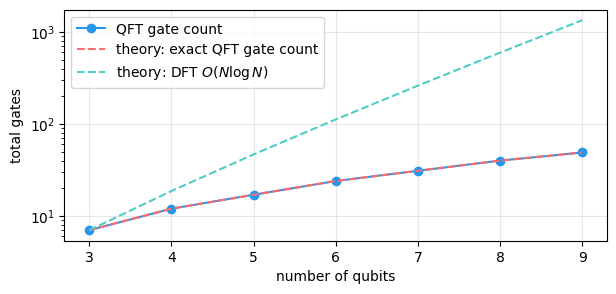

In [10]:
qft_qubit_counts = np.arange(3, 10)
qft_total_gates = []

for n in qft_qubit_counts:
    estimate_n = make_qft_resource_kernel(int(n)).estimate_resources().simplify()
    qft_total_gates.append(int(estimate_n.gates.total))

theoretical_qft_gate_counts = [
    n + n * (n - 1) // 2 + n // 2 for n in qft_qubit_counts
]

dimension_counts = 2**qft_qubit_counts
nlogn_reference = dimension_counts * qft_qubit_counts
nlogn_reference = nlogn_reference / nlogn_reference[0] * qft_total_gates[0]

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(
    qft_qubit_counts,
    qft_total_gates,
    marker="o",
    color="#2696EB",
    label="QFT gate count",
)
ax.plot(
    qft_qubit_counts,
    theoretical_qft_gate_counts,
    linestyle="--",
    color="#FF6B6B",
    label="theory: exact QFT gate count",
)
ax.plot(
    qft_qubit_counts,
    nlogn_reference,
    linestyle="--",
    color="#4ECDC4",
    label=r"theory: DFT $O(N\log N)$",
)
ax.set_xlabel("number of qubits")
ax.set_ylabel("total gates")
ax.set_yscale("log")
ax.set_xticks(qft_qubit_counts)
ax.grid(alpha=0.3)
ax.legend()
plt.show()

assert qft_total_gates == theoretical_qft_gate_counts
assert len(theoretical_qft_gate_counts) == len(qft_total_gates)
assert len(nlogn_reference) == len(qft_total_gates)

## まとめ

このノートブックでは、古典DFTからQFTを導入し、4量子ビットの周波数推定の例を実装して、出力のサンプリングと計算量のスケーリングを確認しました。

- DFTは有限ベクトルを周波数に分解します。QFTは同じ変換を量子振幅に適用します。
- 4量子ビットの例では、単一周波数の位相パターンを準備し、QFTを適用して、サンプルされたヒストグラムから主要な周波数を推定します。
- Qamomileでは、`qamomile.circuit.stdlib.qft.qft`で`Vector[Qubit]`に直接QFTを適用できます。
- `draw()`、バックエンド実行、`estimate_resources()`により、同じQFT構造の回路表示、サンプル出力、計算量のスケーリングを確認できます。